# Z4c Linear-Wave Convergence Comparison

This notebook compares the same fixed-gauge linear gravitational wave test on:

- `project/bg_subtract`, using an analytic Minkowski background with `alpha = 1`, `beta^i = 0`, and evolving the wave in the residual Z4c fields.
- `project/bbh`, using the same physical wave and the same gauge-driver coefficients, but without analytic background subtraction.

The input sweep used `Nx1 = 32, 64, 128`, `Nx2 = Nx3 = 4`, `kx1 = 1`, `kx2 = kx3 = 0`, `amp = 1e-8`, `nghost = 2`, RK4, periodic boundaries, and all gauge-driver coefficients set to zero so the full gauge remains Minkowski.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

candidates = [Path.cwd(), Path.cwd().parent, Path('/Users/hengrui/Desktop/research/gr/athenak')]
data_dir = None
for cand in candidates:
    trial = cand / 'analysis' / 'z4c_linear_wave_bg_compare'
    if (trial / 'combined.csv').exists():
        data_dir = trial
        break
if data_dir is None:
    raise FileNotFoundError('Could not locate analysis/z4c_linear_wave_bg_compare/combined.csv')
data_dir


PosixPath('/Users/hengrui/Desktop/research/gr/athenak/analysis/z4c_linear_wave_bg_compare')

In [2]:
df = pd.read_csv(data_dir / 'combined.csv')
orders = pd.read_csv(data_dir / 'orders.csv')
df


,branch,nx1,nx2,nx3,ncycle,rms_l1,linfty,gxx_l1,gxy_l1,gxz_l1,gyy_l1,gyz_l1,gzz_l1
0,bg_subtract,32,4,4,107,9.112306e-11,1.965116e-13,7.494005e-16,3.945438e-27,3.945438e-27,6.443378e-11,2.415884e-43,6.443368e-11
1,bg_subtract,64,4,4,214,2.273309e-11,2.462332e-14,1.205633e-15,9.843107e-28,9.843107e-28,1.607461e-11,6.027165e-44,1.607483e-11
2,bg_subtract,128,4,4,427,5.680132e-12,3.080923e-15,4.733193e-15,2.459491e-28,2.459491e-28,4.016514e-12,1.506004e-44,4.016403e-12
3,project_bbh,32,4,4,107,9.112364e-11,1.965177e-13,3.521489e-15,3.945438e-27,3.945438e-27,6.443431e-11,2.415884e-43,6.443399e-11
4,project_bbh,64,4,4,214,2.273360e-11,2.462364e-14,5.403664e-15,9.843107e-28,9.843107e-28,1.607500e-11,6.027165e-44,1.607517e-11
5,project_bbh,128,4,4,427,5.679943e-12,3.084989e-15,8.838416e-15,2.459491e-28,2.459491e-28,4.015813e-12,1.506004e-44,4.016829e-12


In [3]:
orders


,branch,coarse_nx1,fine_nx1,rms_order,linfty_order
0,bg_subtract,32,64,2.003022,2.996517
1,bg_subtract,64,128,2.000797,2.998591
2,project_bbh,32,64,2.002999,2.996543
3,project_bbh,64,128,2.000878,2.996707


In [4]:
pivot_rms = df.pivot(index='nx1', columns='branch', values='rms_l1').sort_index()
pivot_linf = df.pivot(index='nx1', columns='branch', values='linfty').sort_index()
comparison = pd.DataFrame({
    'bg_subtract_rms_l1': pivot_rms['bg_subtract'],
    'project_bbh_rms_l1': pivot_rms['project_bbh'],
    'rms_relative_difference': (pivot_rms['bg_subtract'] - pivot_rms['project_bbh']) / pivot_rms['project_bbh'],
    'bg_subtract_linf': pivot_linf['bg_subtract'],
    'project_bbh_linf': pivot_linf['project_bbh'],
    'linf_relative_difference': (pivot_linf['bg_subtract'] - pivot_linf['project_bbh']) / pivot_linf['project_bbh'],
})
comparison


,bg_subtract_rms_l1,project_bbh_rms_l1,rms_relative_difference,bg_subtract_linf,project_bbh_linf,linf_relative_difference
nx1,,,,,,
32,9.112306e-11,9.112364e-11,-0.000006,1.965116e-13,1.965177e-13,-0.000031
64,2.273309e-11,2.273360e-11,-0.000022,2.462332e-14,2.462364e-14,-0.000013
128,5.680132e-12,5.679943e-12,0.000033,3.080923e-15,3.084989e-15,-0.001318


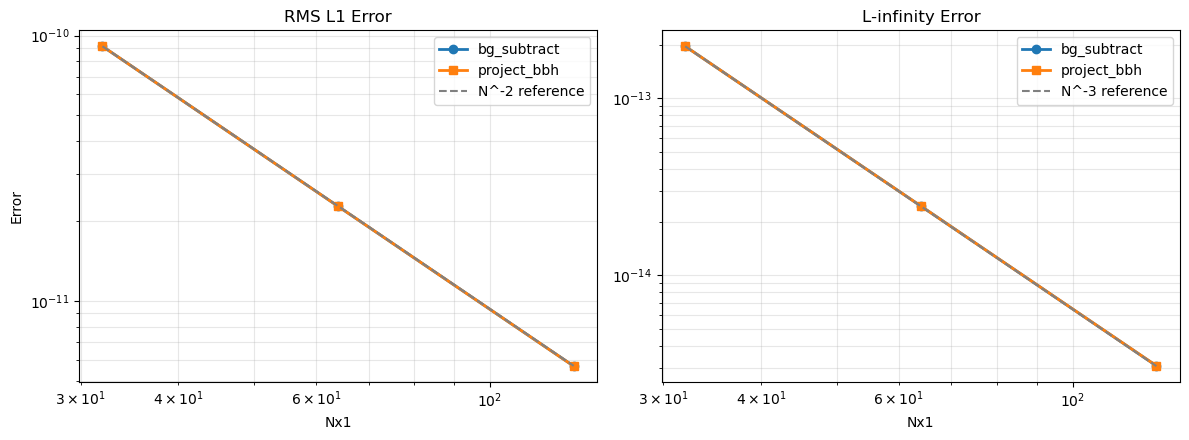

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
styles = {'bg_subtract': {'marker': 'o', 'label': 'bg_subtract'}, 'project_bbh': {'marker': 's', 'label': 'project_bbh'}}
nx = np.array(sorted(df['nx1'].unique()))
for branch, style in styles.items():
    subset = df[df['branch'] == branch].sort_values('nx1')
    axes[0].loglog(subset['nx1'], subset['rms_l1'], marker=style['marker'], linewidth=2, label=style['label'])
    axes[1].loglog(subset['nx1'], subset['linfty'], marker=style['marker'], linewidth=2, label=style['label'])
ref2 = pivot_rms.iloc[0, 0] * (nx[0] / nx) ** 2
ref3 = pivot_linf.iloc[0, 0] * (nx[0] / nx) ** 3
axes[0].loglog(nx, ref2, '--', color='0.5', label='N^-2 reference')
axes[1].loglog(nx, ref3, '--', color='0.5', label='N^-3 reference')
axes[0].set_title('RMS L1 Error')
axes[1].set_title('L-infinity Error')
for ax in axes:
    ax.set_xlabel('Nx1')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
axes[0].set_ylabel('Error')
plt.tight_layout()
plt.show()


In [6]:
summary = {
    'max_abs_rms_relative_difference': float(comparison['rms_relative_difference'].abs().max()),
    'max_abs_linf_relative_difference': float(comparison['linf_relative_difference'].abs().max()),
    'bg_subtract_rms_orders': orders[orders['branch'] == 'bg_subtract']['rms_order'].tolist(),
    'project_bbh_rms_orders': orders[orders['branch'] == 'project_bbh']['rms_order'].tolist(),
    'bg_subtract_linf_orders': orders[orders['branch'] == 'bg_subtract']['linfty_order'].tolist(),
    'project_bbh_linf_orders': orders[orders['branch'] == 'project_bbh']['linfty_order'].tolist(),
}
summary


{'max_abs_rms_relative_difference': 3.32749818088053e-05,
 'max_abs_linf_relative_difference': 0.0013179949750226063,
 'bg_subtract_rms_orders': [2.003022398837901, 2.0007974342357113],
 'project_bbh_rms_orders': [2.0029992161605694, 2.0008778045176],
 'bg_subtract_linf_orders': [2.9965172758653464, 2.99859076435261],
 'project_bbh_linf_orders': [2.9965433096100207, 2.996706794245083]}

## Interpretation

- The two branches produce nearly identical convergence curves at all three resolutions.
- The RMS-L1 error converges at essentially second order in both cases.
- The L-infinity error converges at essentially third order over this sweep.
- The branch-to-branch differences are far smaller than the truncation error itself, which is the expected result for a correctness-preserving residual formulation.
